# MR4010 Navegacion Autonoma — Behavioral Cloning (PyTorch)

### Entrenamiento de un modelo CNN para evasion de vehiculos mediante imitacion de conducta

Este notebook entrena una red neuronal convolucional (NVIDIA DAVE-2) sobre el dataset  
capturado con `dataset_mode_v3` desde Webots. El modelo aprende a **imitar la conducta humana**  
para ejecutar tres fases:

| Fase | Descripcion |
|------|-------------|
| 0 — NORMAL   | Seguimiento de carril izquierdo |
| 1 — EVADING  | Cambio al carril derecho al detectar un vehiculo |
| 2 — RETURNING| Regreso al carril izquierdo una vez despejado |

**Salida del modelo:** angulo de direccion (radianes)  
**Framework:** PyTorch con mixed precision (AMP) — compatible con RTX 5080 (Blackwell SM 12.0)  
**Export:** TorchScript `.pt` listo para usar en el controlador Webots sin instalar PyTorch

## Paso 1 — Verificar GPU

In [7]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice activo:", DEVICE)

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)
VRAM: 17.1 GB

Device activo: cuda


## Paso 2 — Cargar bibliotecas

In [8]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Bibliotecas cargadas.")

Bibliotecas cargadas.


## Paso 3 — Rutas del proyecto

In [9]:
BASE_DIR    = r"D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion"
DATASET_DIR = os.path.join(BASE_DIR, "data", "behavioral_dataset")
IMAGES_DIR  = os.path.join(DATASET_DIR, "images")
CSV_PATH    = os.path.join(DATASET_DIR, "measurements.csv")
MODELS_DIR  = os.path.join(BASE_DIR, "models")

# TorchScript: no requiere la clase DAVE2 para cargar (listo para el controlador)
MODEL_SCRIPT_PATH  = os.path.join(MODELS_DIR, "bc_evasion_model.pt")
# State dict: requiere la clase DAVE2 pero mas ligero
MODEL_WEIGHTS_PATH = os.path.join(MODELS_DIR, "bc_evasion_weights.pt")
CONFIG_PATH        = os.path.join(MODELS_DIR, "bc_evasion_config.json")

os.makedirs(MODELS_DIR, exist_ok=True)

print("CSV:   ", CSV_PATH)
print("Images:", IMAGES_DIR)
print("Model: ", MODEL_SCRIPT_PATH)

CSV:    D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\behavioral_dataset\measurements.csv
Images: D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\behavioral_dataset\images
Model:  D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\bc_evasion_model.pt


## Paso 4 — Cargar y explorar el dataset

In [10]:
df = pd.read_csv(CSV_PATH)

print(f"Total de muestras: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print()
df.head(5)

Total de muestras: 1362
Columnas: ['session_id', 'timestamp', 'image_filename', 'steering_angle', 'speed_kmh', 'brake', 'autonomous_mode', 'line_detected', 'gps_x', 'gps_y', 'lidar_obstacle_detected', 'lidar_obstacle_distance', 'evasion_phase', 'obstacle_type']



,session_id,timestamp,image_filename,steering_angle,speed_kmh,brake,autonomous_mode,line_detected,gps_x,gps_y,lidar_obstacle_detected,lidar_obstacle_distance,evasion_phase,obstacle_type
0,20260612_000237,2026-06-12T07:02:37.489,frame_000001.jpg,0.0,18.59,0.4823,0,0,-45.580,48.056,1,23.55,0,OBJECT_AHEAD
1,20260612_000237,2026-06-12T07:02:38.003,frame_000002.jpg,0.0,22.67,0.4823,0,1,-47.212,48.075,0,NaN,0,NaN
2,20260612_000237,2026-06-12T07:02:38.518,frame_000003.jpg,0.0,25.18,0.4823,0,1,-49.200,48.095,0,NaN,0,NaN
3,20260612_000237,2026-06-12T07:02:39.019,frame_000004.jpg,0.0,29.88,0.4823,0,1,-51.806,48.122,0,NaN,0,NaN
4,20260612_000237,2026-06-12T07:02:39.531,frame_000005.jpg,0.0,33.96,0.4823,0,0,-54.995,48.154,0,NaN,0,NaN


In [11]:
print("Sesiones de grabacion:")
print(df.groupby('session_id').size().rename('frames'))
print()
print("Distribucion de evasion_phase:")
print(df['evasion_phase'].value_counts().sort_index())
print()
print("Modos (0=manual, 1=autonomo):")
print(df['autonomous_mode'].value_counts())
print()
print("Estadisticas de steering_angle:")
print(df['steering_angle'].describe())

Sesiones de grabacion:
session_id
20260612_000237    1362
Name: frames, dtype: int64

Distribucion de evasion_phase:
evasion_phase
0    959
1    115
2    288
Name: count, dtype: int64

Modos (0=manual, 1=autonomo):
autonomous_mode
0    1362
Name: count, dtype: int64

Estadisticas de steering_angle:
count    1362.000000
mean       -0.034765
std         0.065250
min        -0.337700
25%        -0.085100
50%         0.000000
75%         0.000000
max         0.216800
Name: steering_angle, dtype: float64


## Paso 5 — Filtrar y limpiar el dataset

In [12]:
# Solo muestras de conduccion manual (expert demonstrations)
df = df[df['autonomous_mode'] == 0].copy()
print(f"Muestras modo manual: {len(df)}")

# Verificar que las imagenes existen en disco
df['image_path'] = df['image_filename'].apply(lambda f: os.path.join(IMAGES_DIR, f))
mask_exists = df['image_path'].apply(os.path.exists)
missing = (~mask_exists).sum()
if missing > 0:
    print(f"ADVERTENCIA: {missing} imagenes no encontradas — eliminadas.")
df = df[mask_exists].copy()

# Limpiar nulos
df = df.dropna(subset=['steering_angle', 'speed_kmh', 'brake']).copy()
df['evasion_phase']           = df['evasion_phase'].astype(int)
df['lidar_obstacle_detected'] = df['lidar_obstacle_detected'].fillna(0).astype(int)
df['lidar_obstacle_distance'] = pd.to_numeric(
    df['lidar_obstacle_distance'], errors='coerce'
).fillna(0.0)

df = df.reset_index(drop=True)
print(f"Muestras limpias: {len(df)}  |  Sesiones: {df['session_id'].nunique()}")

Muestras modo manual: 1362
Muestras limpias: 1362  |  Sesiones: 1


## Paso 6 — Visualizar distribucion de etiquetas

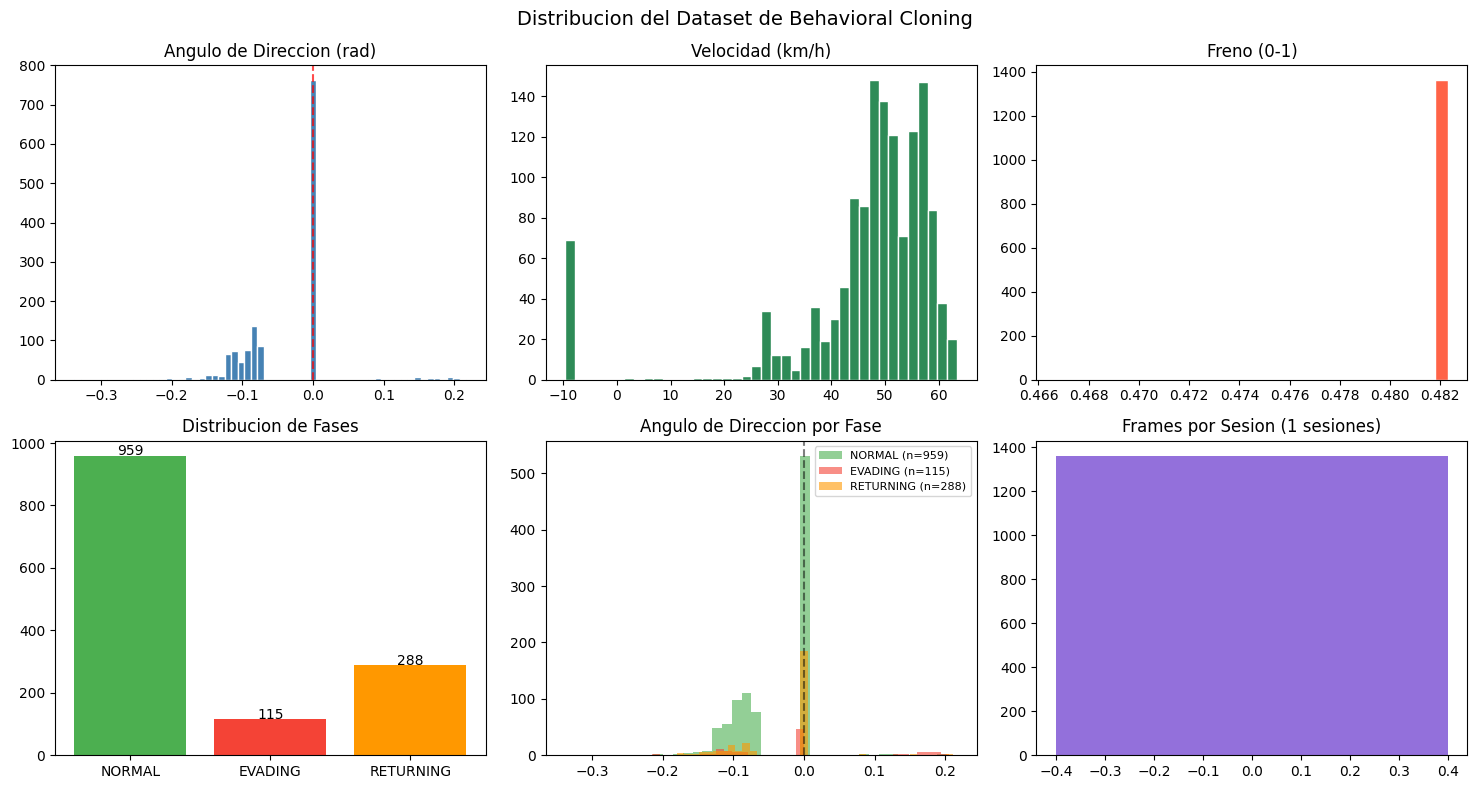

Desbalance de fases:
  Fase 0 NORMAL    :   959 muestras (70.4%)
  Fase 1 EVADING   :   115 muestras (8.4%)
  Fase 2 RETURNING :   288 muestras (21.1%)


In [13]:
phase_labels = {0: 'NORMAL', 1: 'EVADING', 2: 'RETURNING'}
phase_colors = ['#4CAF50', '#F44336', '#FF9800']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribucion del Dataset de Behavioral Cloning', fontsize=14)

axes[0,0].hist(df['steering_angle'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Angulo de Direccion (rad)')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.7)

axes[0,1].hist(df['speed_kmh'], bins=40, color='seagreen', edgecolor='white')
axes[0,1].set_title('Velocidad (km/h)')

axes[0,2].hist(df['brake'], bins=30, color='tomato', edgecolor='white')
axes[0,2].set_title('Freno (0-1)')

phase_counts = df['evasion_phase'].value_counts().sort_index()
axes[1,0].bar(
    [phase_labels[p] for p in phase_counts.index],
    phase_counts.values,
    color=[phase_colors[p] for p in phase_counts.index]
)
axes[1,0].set_title('Distribucion de Fases')
for i, v in enumerate(phase_counts.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontsize=10)

for phase, color, label in zip([0,1,2], phase_colors, ['NORMAL','EVADING','RETURNING']):
    subset = df[df['evasion_phase'] == phase]['steering_angle']
    if len(subset) > 0:
        axes[1,1].hist(subset, bins=40, alpha=0.6, color=color, label=f'{label} (n={len(subset)})')
axes[1,1].set_title('Angulo de Direccion por Fase')
axes[1,1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1,1].legend(fontsize=8)

sess_counts = df['session_id'].value_counts()
axes[1,2].bar(range(len(sess_counts)), sess_counts.values, color='mediumpurple')
axes[1,2].set_title(f'Frames por Sesion ({len(sess_counts)} sesiones)')

plt.tight_layout()
plt.show()

print("Desbalance de fases:")
for p, label in phase_labels.items():
    n = (df['evasion_phase'] == p).sum()
    print(f"  Fase {p} {label:10s}: {n:5d} muestras ({100*n/len(df):.1f}%)")

## Paso 7 — Visualizar imagenes de ejemplo por fase

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle('Imagenes de ejemplo por fase de evasion', fontsize=13)

for row_idx, (phase, label) in enumerate([(0,'NORMAL'),(1,'EVADING'),(2,'RETURNING')]):
    subset = df[df['evasion_phase'] == phase]
    n = min(4, len(subset))
    if n == 0:
        for col in range(4):
            axes[row_idx, col].axis('off')
        continue
    sample = subset.sample(n, random_state=SEED)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = cv2.imread(r['image_path'])
        if img is None:
            axes[row_idx, col].axis('off')
            continue
        axes[row_idx, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row_idx, col].set_title(f"{label}\nangle={r['steering_angle']:.3f}", fontsize=8)
        axes[row_idx, col].axis('off')
    for col in range(n, 4):
        axes[row_idx, col].axis('off')

plt.tight_layout()
plt.show()

## Paso 8 — Division por sesion (train / validacion)

> **Importante:** la division es **por sesion completa**, no por frame aleatorio.  
> Dividir por frame causa *data leakage*: frames consecutivos son casi identicos.

In [14]:
sessions = sorted(df['session_id'].unique())
print("Sesiones disponibles:", sessions)

# Ultima sesion = validacion, resto = train
val_session    = sessions[-1]
train_sessions = sessions[:-1]

if len(train_sessions) == 0:
    split    = int(len(df) * 0.8)
    df_train = df.iloc[:split].copy()
    df_val   = df.iloc[split:].copy()
    print("Solo una sesion — split temporal 80/20")
else:
    df_train = df[df['session_id'].isin(train_sessions)].copy()
    df_val   = df[df['session_id'] == val_session].copy()

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"Train: {len(df_train)} muestras ({df_train['session_id'].nunique()} sesiones)")
print(f"Val:   {len(df_val)} muestras  (sesion: {val_session})")
print("\nFases en Train:"); print(df_train['evasion_phase'].value_counts().sort_index())
print("\nFases en Val:");   print(df_val['evasion_phase'].value_counts().sort_index())

Sesiones disponibles: ['20260612_000237']
Solo una sesion — split temporal 80/20
Train: 1089 muestras (1 sesiones)
Val:   273 muestras  (sesion: 20260612_000237)

Fases en Train:
evasion_phase
0    786
1     84
2    219
Name: count, dtype: int64

Fases en Val:
evasion_phase
0    173
1     31
2     69
Name: count, dtype: int64


## Paso 9 — Preprocesamiento de imagenes

**Recorte:** 38% superior (cielo) y 12% inferior (capo).  
**Resize:** 66x200 px (NVIDIA DAVE-2).  
**Normalizacion:** [0.0, 1.0] float32.

> Esta funcion debe ser **identica** en el controlador Webots y en este notebook.

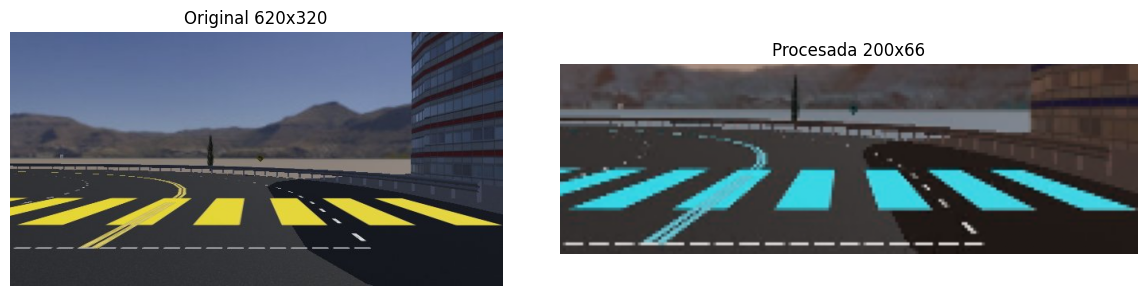

In [15]:
IMG_H       = 66
IMG_W       = 200
CROP_TOP    = 0.38
CROP_BOTTOM = 0.88


def preprocess_image(img_bgr, augment=False):
    """Preprocesa un frame BGR de Webots para el modelo BC."""
    h, w = img_bgr.shape[:2]
    y1 = int(h * CROP_TOP)
    y2 = int(h * CROP_BOTTOM)
    cropped = img_bgr[y1:y2, :]
    resized = cv2.resize(cropped, (IMG_W, IMG_H))
    img = resized.astype(np.float32) / 255.0

    if augment:
        img = np.clip(img + np.random.uniform(-0.3, 0.3), 0.0, 1.0)
        img = np.clip(img + np.random.normal(0, 0.02, img.shape).astype(np.float32),
                      0.0, 1.0)
    return img  # HWC float32


# Verificar visualmente
sample_img = cv2.imread(df['image_path'].iloc[0])
processed  = preprocess_image(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original {sample_img.shape[1]}x{sample_img.shape[0]}')
axes[0].axis('off')
axes[1].imshow(processed)
axes[1].set_title(f'Procesada {IMG_W}x{IMG_H}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Paso 10 — Dataset PyTorch y DataLoader

In [16]:
class BCDataset(Dataset):
    """
    Dataset de Behavioral Cloning.
    flip=True duplica cada muestra con volteo horizontal (angulo negado).
    """

    def __init__(self, df, augment=False, flip=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.n_base  = len(self.df)
        self.flip    = flip
        self.length  = self.n_base * 2 if flip else self.n_base

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        is_flipped = self.flip and (idx >= self.n_base)
        real_idx   = idx % self.n_base
        row        = self.df.iloc[real_idx]

        img = cv2.imread(row['image_path'])
        if img is None:
            img = np.zeros((320, 620, 3), dtype=np.uint8)

        img   = preprocess_image(img, augment=self.augment)
        angle = float(row['steering_angle'])

        if is_flipped:
            img   = img[:, ::-1, :].copy()
            angle = -angle

        # HWC -> CHW para PyTorch
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        return img_tensor, torch.tensor(angle, dtype=torch.float32)


# Verificar
test_ds = BCDataset(df_train.head(10), augment=False, flip=True)
img_t, ang_t = test_ds[0]
print(f"Tensor imagen: {img_t.shape}  dtype={img_t.dtype}")
print(f"Angulo:        {ang_t.item():.4f} rad")
print(f"Dataset size (con flip): {len(test_ds)}")

Tensor imagen: torch.Size([3, 66, 200])  dtype=torch.float32
Angulo:        0.0000 rad
Dataset size (con flip): 20


## Paso 11 — Pesos de fase y DataLoaders

`WeightedRandomSampler` sobremuestra automaticamente las fases minoritarias  
(EVADING y RETURNING) para que el modelo no ignore la maniobra de evasion.

In [17]:
BATCH_SIZE    = 32
NUM_WORKERS   = 0   # 0 en Windows para evitar errores de multiprocessing
PHASE_WEIGHTS = {0: 1.0, 1: 5.0, 2: 4.0}

train_dataset = BCDataset(df_train, augment=True,  flip=True)
val_dataset   = BCDataset(df_val,   augment=False, flip=False)

# Pesos por muestra (se duplican para cubrir las muestras flipeadas)
base_weights   = df_train['evasion_phase'].map(PHASE_WEIGHTS).values.tolist()
sample_weights = base_weights + base_weights
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train batches: {len(train_loader)}  ({len(train_dataset)} muestras con flip)")
print(f"Val batches:   {len(val_loader)}  ({len(val_dataset)} muestras)")
print("\nPesos de fase:")
for p, w in PHASE_WEIGHTS.items():
    n = (df_train['evasion_phase'] == p).sum()
    print(f"  Fase {p} {phase_labels[p]:10s}: peso={w:.1f}  n={n}")

Train batches: 69  (2178 muestras con flip)
Val batches:   9  (273 muestras)

Pesos de fase:
  Fase 0 NORMAL    : peso=1.0  n=786
  Fase 1 EVADING   : peso=5.0  n=84
  Fase 2 RETURNING : peso=4.0  n=219


## Paso 12 — Arquitectura del modelo CNN (NVIDIA DAVE-2)

```
Input (3, 66, 200)  CHW
  Conv2d(3  -> 24, 5x5, s=2) + ELU  -> (24, 31, 98)
  Conv2d(24 -> 36, 5x5, s=2) + ELU  -> (36, 14, 47)
  Conv2d(36 -> 48, 5x5, s=2) + ELU  -> (48,  5, 22)
  Conv2d(48 -> 64, 3x3, s=1) + ELU  -> (64,  3, 20)
  Conv2d(64 -> 64, 3x3, s=1) + ELU  -> (64,  1, 18)
  Flatten -> 1152
  Linear(1152->100) + ELU + Dropout(0.3)
  Linear(100 -> 50) + ELU + Dropout(0.2)
  Linear( 50 -> 10) + ELU
  Linear( 10 ->  1)  -> steering_angle
```

In [18]:
class DAVE2(nn.Module):
    """NVIDIA DAVE-2 para Behavioral Cloning en Webots. Input CHW (3, 66, 200)."""

    def __init__(self, dropout_1=0.3, dropout_2=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  24, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2), nn.ELU(),
            nn.Conv2d(48, 64, kernel_size=3, stride=1), nn.ELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ELU(),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, 100), nn.ELU(), nn.Dropout(dropout_1),
            nn.Linear(100,  50),  nn.ELU(), nn.Dropout(dropout_2),
            nn.Linear(50,   10),  nn.ELU(),
            nn.Linear(10,    1)
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)


model = DAVE2().to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_H, IMG_W).to(DEVICE)
    out   = model(dummy)
    print("Input shape: ", dummy.shape)
    print("Output shape:", out.shape)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parametros totales: {total_params:,}")

Input shape:  torch.Size([1, 3, 66, 200])
Output shape: torch.Size([1])
Parametros totales: 252,219


## Paso 13 — Resumen del modelo

In [19]:
print(model)
print()
print(f"{'Layer':<35} {'Params':>10}")
print("-" * 47)
for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        params = sum(p.numel() for p in module.parameters())
        print(f"{name:<35} {params:>10,}")

DAVE2(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ELU(alpha=1.0)
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ELU(alpha=1.0)
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ELU(alpha=1.0)
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ELU(alpha=1.0)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ELU(alpha=1.0)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ELU(alpha=1.0)
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=50, out_features=10, bias=True)
    (8): ELU(alpha=1.0)
    (9): Linear(in_features=10, out_features=1, bias=True)
  )
)

Layer                                   Params
---------------------------------

## Paso 14 — Configurar entrenamiento

In [23]:
EPOCHS      = 40
LR          = 1e-4
PATIENCE    = 8    # early stopping
LR_PATIENCE = 4    # reducir LR si no mejora

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=LR_PATIENCE
)

# AMP: 2-3x mas rapido en RTX con Tensor Cores; compatible con Blackwell SM 12.0
scaler = GradScaler(enabled=torch.cuda.is_available())

print(f"Optimizer : Adam  lr={LR}")
print(f"Loss      : MSELoss")
print(f"AMP (fp16): {torch.cuda.is_available()}")
print(f"Early stop: patience={PATIENCE} epocas")

Optimizer : Adam  lr=0.0001
Loss      : MSELoss
AMP (fp16): True
Early stop: patience=8 epocas


C:\Users\baraj\AppData\Local\Temp\ipykernel_17624\2775119437.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


## Paso 15 — Entrenar el modelo

In [24]:
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

best_val_loss    = float('inf')
best_epoch       = 0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_mae  = 0.0

    for imgs, angles in train_loader:
        imgs   = imgs.to(DEVICE)
        angles = angles.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=torch.cuda.is_available()):
            preds = model(imgs)
            loss  = criterion(preds, angles)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_mae  += torch.abs(preds.detach() - angles).mean().item()

    train_loss /= len(train_loader)
    train_mae  /= len(train_loader)

    # ── Validacion ───────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_mae  = 0.0

    with torch.no_grad():
        for imgs, angles in val_loader:
            imgs   = imgs.to(DEVICE)
            angles = angles.to(DEVICE)
            with autocast(enabled=torch.cuda.is_available()):
                preds = model(imgs)
                loss  = criterion(preds, angles)
            val_loss += loss.item()
            val_mae  += torch.abs(preds - angles).mean().item()

    val_loss /= len(val_loader)
    val_mae  /= len(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    # ── Checkpoint + Early stopping ──────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_WEIGHTS_PATH)
        tag = '* BEST'
    else:
        patience_counter += 1
        tag = f'({patience_counter}/{PATIENCE})'

    lr_now = optimizer.param_groups[0]['lr']
    print(f"Ep {epoch:03d}/{EPOCHS}  "
          f"loss={train_loss:.5f}  val_loss={val_loss:.5f}  "
          f"mae={train_mae:.5f}  val_mae={val_mae:.5f}  "
          f"lr={lr_now:.2e}  {tag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping en epoca {epoch}. Mejor: epoca {best_epoch}.")
        break

# Restaurar mejor modelo
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=DEVICE))
print(f"\nMejor modelo restaurado (epoca {best_epoch}, val_loss={best_val_loss:.6f})")

C:\Users\baraj\AppData\Local\Temp\ipykernel_17624\3901942167.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
C:\Users\baraj\AppData\Local\Temp\ipykernel_17624\3901942167.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Ep 001/40  loss=0.01364  val_loss=0.00747  mae=0.08941  val_mae=0.06446  lr=1.00e-04  * BEST
Ep 002/40  loss=0.00750  val_loss=0.00618  mae=0.06450  val_mae=0.05493  lr=1.00e-04  * BEST
Ep 003/40  loss=0.00609  val_loss=0.00351  mae=0.05894  val_mae=0.04382  lr=1.00e-04  * BEST
Ep 004/40  loss=0.00508  val_loss=0.00389  mae=0.05348  val_mae=0.04728  lr=1.00e-04  (1/8)
Ep 005/40  loss=0.00440  val_loss=0.00317  mae=0.05204  val_mae=0.04033  lr=1.00e-04  * BEST
Ep 006/40  loss=0.00405  val_loss=0.00269  mae=0.04972  val_mae=0.03852  lr=1.00e-04  * BEST
Ep 007/40  loss=0.00394  val_loss=0.00260  mae=0.04848  val_mae=0.03723  lr=1.00e-04  * BEST
Ep 008/40  loss=0.00367  val_loss=0.00301  mae=0.04646  val_mae=0.03907  lr=1.00e-04  (1/8)
Ep 009/40  loss=0.00359  val_loss=0.00287  mae=0.04628  val_mae=0.03979  lr=1.00e-04  (2/8)
Ep 010/40  loss=0.00380  val_loss=0.00276  mae=0.04701  val_mae=0.03771  lr=1.00e-04  (3/8)
Ep 011/40  loss=0.00340  val_loss=0.00279  mae=0.04563  val_mae=0.03723  l

## Paso 16 — Curvas de entrenamiento

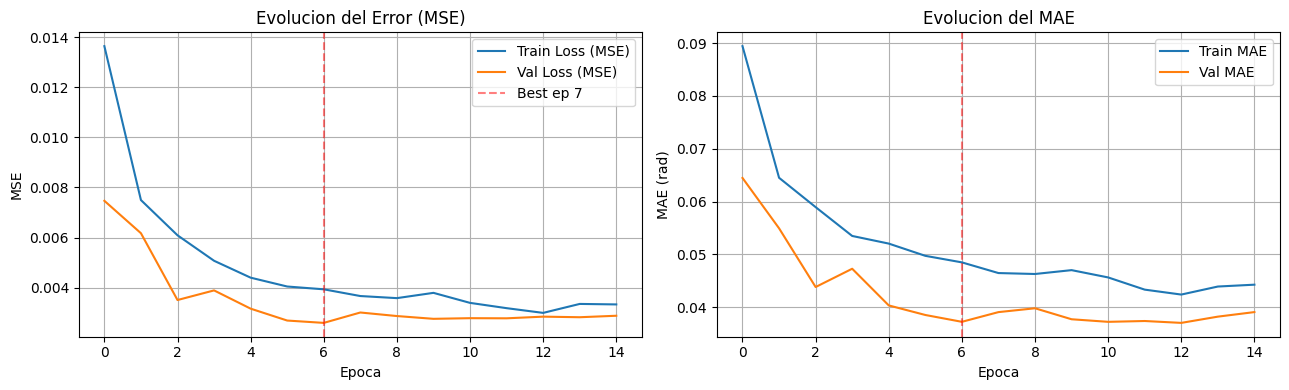

Mejor epoca: 7
Mejor val_loss (MSE): 0.002599
Mejor val_mae:        0.037230 rad


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train Loss (MSE)')
axes[0].plot(history['val_loss'],   label='Val Loss (MSE)')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5,
                label=f'Best ep {best_epoch}')
axes[0].set_title('Evolucion del Error (MSE)')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_mae'], label='Train MAE')
axes[1].plot(history['val_mae'],   label='Val MAE')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Evolucion del MAE')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE (rad)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Mejor epoca: {best_epoch}")
print(f"Mejor val_loss (MSE): {best_val_loss:.6f}")
print(f"Mejor val_mae:        {history['val_mae'][best_epoch-1]:.6f} rad")

## Paso 17 — Resumen del modelo (post-entrenamiento)

In [26]:
print(model)
print(f"\nParametros totales: {sum(p.numel() for p in model.parameters()):,}")

DAVE2(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ELU(alpha=1.0)
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ELU(alpha=1.0)
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ELU(alpha=1.0)
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ELU(alpha=1.0)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ELU(alpha=1.0)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ELU(alpha=1.0)
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=50, out_features=10, bias=True)
    (8): ELU(alpha=1.0)
    (9): Linear(in_features=10, out_features=1, bias=True)
  )
)

Parametros totales: 252,219


## Paso 18 — Evaluar el modelo

In [27]:
model.eval()
y_true_all = []
y_pred_all = []
phases_all = []

with torch.no_grad():
    for _, row in df_val.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None:
            continue
        img_proc = preprocess_image(img, augment=False)
        t = torch.from_numpy(img_proc).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        pred = model(t).item()
        y_true_all.append(float(row['steering_angle']))
        y_pred_all.append(float(pred))
        phases_all.append(int(row['evasion_phase']))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
phases_all = np.array(phases_all)

mae  = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))

print(f"{'='*50}")
print(f"  Evaluacion global (validacion)")
print(f"  MAE  = {mae:.5f} rad  (~{np.degrees(mae):.2f} grados)")
print(f"  RMSE = {rmse:.5f} rad")
print(f"{'='*50}")

print("\nError por fase:")
for phase, label in phase_labels.items():
    mask = phases_all == phase
    if mask.sum() == 0:
        print(f"  Fase {phase} {label:10s}: sin muestras")
        continue
    p_mae  = mean_absolute_error(y_true_all[mask], y_pred_all[mask])
    p_rmse = np.sqrt(mean_squared_error(y_true_all[mask], y_pred_all[mask]))
    print(f"  Fase {phase} {label:10s}: MAE={p_mae:.5f}  RMSE={p_rmse:.5f}  n={mask.sum()}")

  Evaluacion global (validacion)
  MAE  = 0.03706 rad  (~2.12 grados)
  RMSE = 0.05077 rad

Error por fase:
  Fase 0 NORMAL    : MAE=0.03318  RMSE=0.04671  n=173
  Fase 1 EVADING   : MAE=0.05020  RMSE=0.07125  n=31
  Fase 2 RETURNING : MAE=0.04088  RMSE=0.04947  n=69


## Paso 19 — Scatter: predicciones vs reales

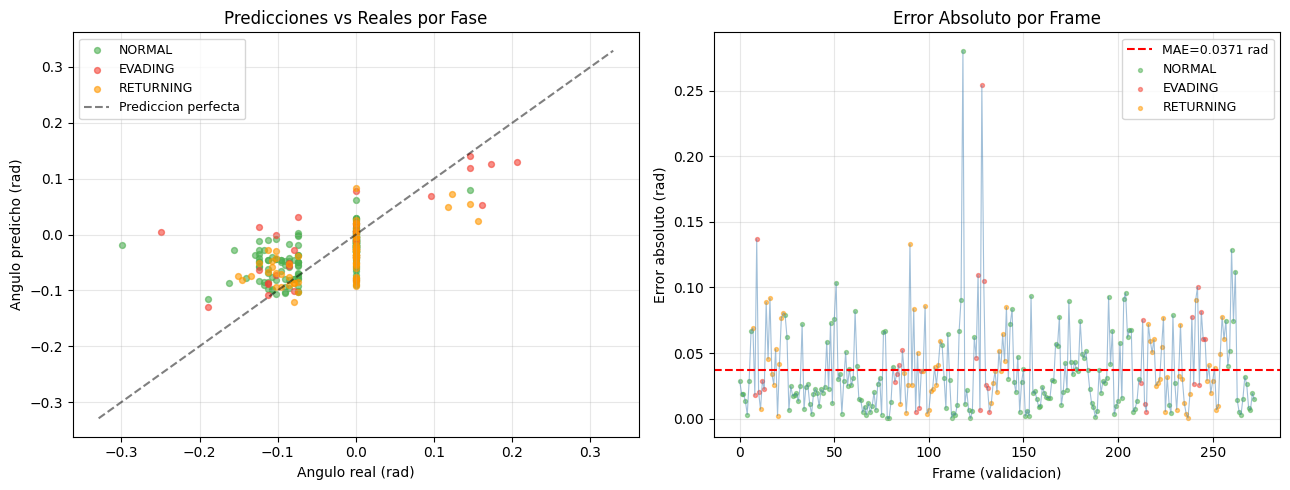

In [28]:
phase_colors_map = {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for phase, label in phase_labels.items():
    mask = phases_all == phase
    if mask.sum() == 0:
        continue
    axes[0].scatter(
        y_true_all[mask], y_pred_all[mask],
        c=phase_colors_map[phase], label=label, alpha=0.6, s=18
    )

lim = max(abs(y_true_all).max(), abs(y_pred_all).max()) * 1.1
axes[0].plot([-lim, lim], [-lim, lim], 'k--', alpha=0.5, label='Prediccion perfecta')
axes[0].set_xlabel('Angulo real (rad)')
axes[0].set_ylabel('Angulo predicho (rad)')
axes[0].set_title('Predicciones vs Reales por Fase')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

abs_error = np.abs(y_true_all - y_pred_all)
axes[1].plot(abs_error, alpha=0.5, color='steelblue', linewidth=0.8)
axes[1].axhline(mae, color='red', linestyle='--', label=f'MAE={mae:.4f} rad')
for phase, color in phase_colors_map.items():
    mask = phases_all == phase
    if mask.sum() > 0:
        axes[1].scatter(np.where(mask)[0], abs_error[mask],
                        c=color, s=8, alpha=0.5, label=phase_labels[phase])
axes[1].set_xlabel('Frame (validacion)')
axes[1].set_ylabel('Error absoluto (rad)')
axes[1].set_title('Error Absoluto por Frame')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 20 — Visualizar predicciones sobre imagenes reales

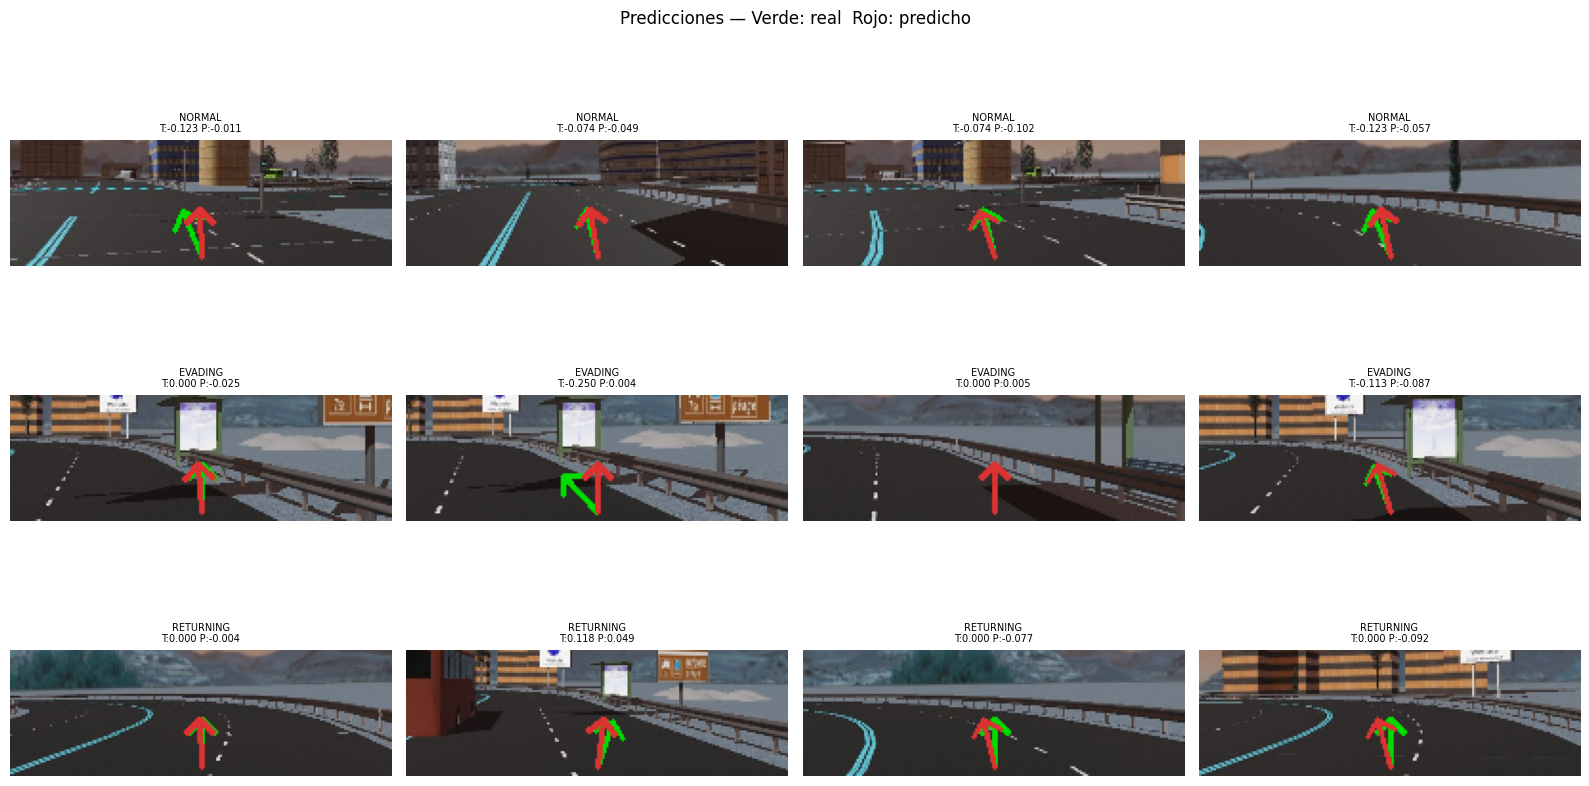

In [29]:
def draw_steering_overlay(img_rgb, true_angle, pred_angle):
    h, w = img_rgb.shape[:2]
    cx, cy, L = w // 2, h - 5, 25
    out = img_rgb.copy()
    tx = int(cx + L * np.sin(true_angle * 3))
    ty = int(cy - L * np.cos(true_angle * 3))
    cv2.arrowedLine(out, (cx, cy), (tx, ty), (0, 220, 0), 2, tipLength=0.4)
    px = int(cx + L * np.sin(pred_angle * 3))
    py = int(cy - L * np.cos(pred_angle * 3))
    cv2.arrowedLine(out, (cx, cy), (px, py), (220, 50, 50), 2, tipLength=0.4)
    return out


sample_rows = []
for phase in [0, 1, 2]:
    subset = df_val[df_val['evasion_phase'] == phase]
    n = min(4, len(subset))
    if n > 0:
        sample_rows.append(subset.sample(n, random_state=SEED))

sample_df = pd.concat(sample_rows).reset_index(drop=True)

model.eval()
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle('Predicciones — Verde: real  Rojo: predicho', fontsize=12)

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i // 4, i % 4]
    img = cv2.imread(row['image_path'])
    if img is None:
        ax.axis('off')
        continue
    img_proc = preprocess_image(img, augment=False)
    t = torch.from_numpy(img_proc).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(t).item()
    true = float(row['steering_angle'])
    vis  = draw_steering_overlay((img_proc * 255).astype(np.uint8), true, pred)
    ax.imshow(vis)
    ax.set_title(
        f"{phase_labels[int(row['evasion_phase'])]}\nT:{true:.3f} P:{pred:.3f}",
        fontsize=7
    )
    ax.axis('off')

for j in range(len(sample_df), 12):
    axes[j // 4, j % 4].axis('off')

plt.tight_layout()
plt.show()

## Paso 21 — Guardar modelo y configuracion

Dos formatos:
- **`bc_evasion_weights.pt`** — state dict (requiere la clase `DAVE2` para cargar)
- **`bc_evasion_model.pt`** — TorchScript traced (no requiere la clase, listo para el controlador)

In [30]:
print("Weights guardados en:", MODEL_WEIGHTS_PATH)

# TorchScript export
model.eval()
dummy_input = torch.zeros(1, 3, IMG_H, IMG_W).to(DEVICE)
traced = torch.jit.trace(model, dummy_input)
torch.jit.save(traced, MODEL_SCRIPT_PATH)
print("TorchScript guardado en:", MODEL_SCRIPT_PATH)

# Config de preprocesamiento
config = {
    "img_h":          IMG_H,
    "img_w":          IMG_W,
    "crop_top":       CROP_TOP,
    "crop_bottom":    CROP_BOTTOM,
    "model_path":     MODEL_SCRIPT_PATH,
    "val_mae_rad":    float(mae),
    "val_rmse_rad":   float(rmse),
    "best_epoch":     best_epoch,
    "train_samples":  len(df_train),
    "val_samples":    len(df_val),
    "phase_weights":  PHASE_WEIGHTS,
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)
print("Config guardado en:", CONFIG_PATH)
print()
print(json.dumps(config, indent=2))

Weights guardados en: D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\bc_evasion_weights.pt
TorchScript guardado en: D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\bc_evasion_model.pt
Config guardado en: D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\bc_evasion_config.json

{
  "img_h": 66,
  "img_w": 200,
  "crop_top": 0.38,
  "crop_bottom": 0.88,
  "model_path": "D:\\ML\\Projects\\Project_5_MR4010.10_Navegacion\\MR4010.10_Navegacion\\models\\bc_evasion_model.pt",
  "val_mae_rad": 0.037056945716417745,
  "val_rmse_rad": 0.05076779133805802,
  "best_epoch": 7,
  "train_samples": 1089,
  "val_samples": 273,
  "phase_weights": {
    "0": 1.0,
    "1": 5.0,
    "2": 4.0
  }
}


## Paso 22 — Cargar modelo y probar inferencia

Modelo TorchScript cargado desde: D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\bc_evasion_model.pt
Fase: 1  Real: 0.0000 rad  Prediccion: 0.0778 rad


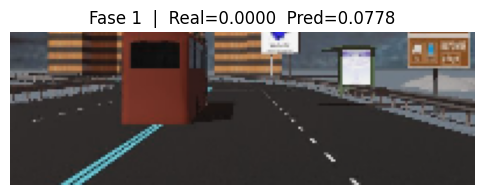

In [33]:
# Cargar TorchScript (no necesita la clase DAVE2)
loaded_model = torch.jit.load(MODEL_SCRIPT_PATH, map_location=DEVICE)
loaded_model.eval()
print("Modelo TorchScript cargado desde:", MODEL_SCRIPT_PATH)

test_row  = df_val.sample(1, random_state=7).iloc[0]
test_img  = cv2.imread(test_row['image_path'])
test_proc = preprocess_image(test_img, augment=False)
test_t    = torch.from_numpy(test_proc).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    test_pred = loaded_model(test_t).item()

print(f"Fase: {test_row['evasion_phase']}  "
      f"Real: {test_row['steering_angle']:.4f} rad  "
      f"Prediccion: {test_pred:.4f} rad")

plt.figure(figsize=(6, 2.5))
plt.imshow(test_proc)
plt.title(
    f"Fase {test_row['evasion_phase']}  |  "
    f"Real={test_row['steering_angle']:.4f}  Pred={test_pred:.4f}"
)
plt.axis('off')
plt.show()

## Paso 23 — Integracion en el controlador Webots

Codigo listo para copiar en `simple_controller_act_2_1_V1.9.py`.  
El modelo BC reemplaza al PID **solo durante fases 1 y 2** (evasion y retorno).

> **Requisito:** `pip install torch` en el entorno Python que usa Webots.

In [ ]:
CONTROLLER_SNIPPET = r"""
# ============================================================
# BEHAVIORAL CLONING — integracion en simple_controller_act_2_1_V1.9.py
# ============================================================
import torch
import numpy as np
import cv2

BC_MODEL_PATH = r"D:\ML\Projects\Project_5_MR4010.10_Navegacion"\
                r"\MR4010.10_Navegacion\models\bc_evasion_model.pt"

# Deben coincidir con los valores del notebook de entrenamiento
BC_IMG_H    = 66
BC_IMG_W    = 200
BC_CROP_TOP = 0.38
BC_CROP_BOT = 0.88
BC_ENABLED  = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar modelo TorchScript una sola vez al inicio
bc_model = None
if BC_ENABLED:
    bc_model = torch.jit.load(BC_MODEL_PATH, map_location=DEVICE)
    bc_model.eval()
    print("[BC] Modelo cargado:", BC_MODEL_PATH)


def bc_preprocess(frame_bgr):
    h, w = frame_bgr.shape[:2]
    y1 = int(h * BC_CROP_TOP)
    y2 = int(h * BC_CROP_BOT)
    crop = frame_bgr[y1:y2, :]
    resized = cv2.resize(crop, (BC_IMG_W, BC_IMG_H))
    return resized.astype(np.float32) / 255.0


def bc_predict_angle(frame_bgr):
    img = bc_preprocess(frame_bgr)
    t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return bc_model(t).item()


# ── En el loop principal (reemplazar PID cuando evasion_phase > 0) ────
#
#   if autonomous_mode:
#       if BC_ENABLED and bc_model and evasion_phase > 0:
#           angle = bc_predict_angle(frame)   # BC maneja la evasion
#       else:
#           angle = pid_angle                 # PID normal
# ============================================================
"""
print(CONTROLLER_SNIPPET)

---
## Notas para el siguiente paso

### Criterios de aceptacion del modelo
- **MAE < 0.05 rad** (~3 grados) para considerar el modelo apto para el controlador.
- Error en Fase 1 (EVADING) debe ser menor o comparable al de Fase 0 (NORMAL).

### Si el error es alto
- Grabar mas sesiones de evasion (objetivo: >= 300 frames de fase 1+2).
- Aumentar `PHASE_WEIGHTS[1]` y `PHASE_WEIGHTS[2]`.
- Reducir `CROP_TOP` si el modelo necesita mas contexto de la escena.

### Para mejorar el modelo
- Agregar la distancia LiDAR como entrada auxiliar (concatenar despues de Flatten).
- Probar backbone MobileNetV2 preentrenado para mejor extraccion de features.